# Генеративные нейросети
## Задание 3

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


**Баллы за задание:**
* Задача 1 &mdash; 60 баллов.
* Задача 2 &mdash; 60 баллов.

-----------

In [1]:
# Bot check

# HW_ID: ds_gen3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

In [226]:
import os
os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"
os.environ["NUMEXPR_NUM_THREADS"] = "20"
os.environ["OPENBLAS_NUM_THREADS"] = "20"
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchsummary import summary
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.models import inception_v3

from sklearn.datasets import make_blobs
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import math
from umap import UMAP

from torch.autograd import Variable
from torchvision.datasets import ImageFolder
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from datetime import datetime
from IPython.display import clear_output
from tqdm.auto import tqdm
import torch.nn.functional as F
from torch.nn.functional import interpolate

from pathlib import Path

from torch.utils.data import ConcatDataset, DataLoader, RandomSampler

from torchvision.datasets import MNIST
from torchvision.transforms import v2
from torchvision.transforms.functional import pil_to_tensor, to_pil_image
from torchvision.utils import make_grid

from diffusers import DDPMScheduler, DDPMPipeline, DDIMPipeline, UNet2DModel
from diffusers.optimization import get_cosine_schedule_with_warmup

from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity

PATH = ""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
sns.set(palette='Set2')

from IPython.display import HTML
from IPython.display import clear_output

seed = 42
import random
random.seed(seed)
torch.manual_seed(seed);

import torch
torch.set_num_threads(20)

In [3]:
import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
USE_CUDA = torch.cuda.is_available()

### Задача 1. Свойства диффузии

**1.**  Проверьте качество генерации изображений для разного количества шагов диффузии.
* Обучите диффузионные модели на датасете MNIST для разного количества шагов диффузии $T$: 100, 200, 400, 700, 1000. При этом фиксируйте $\beta_1$, $\widetilde{\alpha}_T$ во всех случаях должен быть близок к 1. Отобразите график лосса при обучении. 
* Визуализируйте результаты генерации для 5 моделей. Для генераций используйте DDPM-инференс с тем же числом шагов, что при обучении. 
* Постройте график зависимости FID модели генерации от количества шагов диффузии. 
* Сравните качество моделей между собой и с ганами, которые были на прошлых занятиях. Сделайте выводы.

In [4]:
def normalize(image):
    """
    Нормализация для изображений из MNIST
    """
    return (image * 2 - 1).to(torch.float32)

def unnormalize(image):
    return ((image.clamp(-1, 1) + 1) / 2 * 255).to(torch.uint8)

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Lambda(normalize),
])

In [5]:
mnist_train = MNIST(root='.', train=True, transform=transform, download=True)
mnist_test = MNIST(root='.', train=False, transform=transform, download=True)
mnist = ConcatDataset([mnist_train, mnist_test])

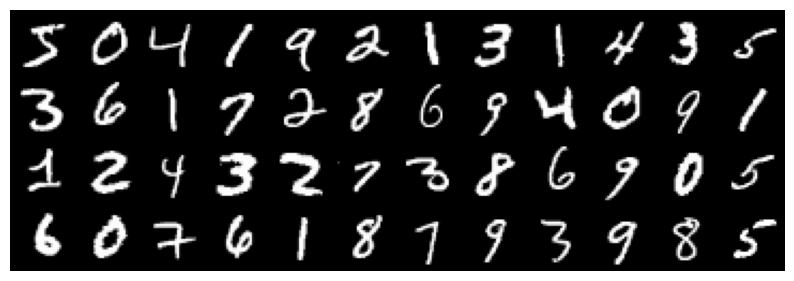

In [6]:
images = [unnormalize(mnist[i][0]) for i in range(48)]
image_grid = to_pil_image(make_grid(images, nrow=12))

plt.figure(figsize=(10, 10))
plt.imshow(image_grid)
plt.axis('off')

plt.show()

In [7]:
batch_size = 128
dataloader = DataLoader(
    mnist,
    batch_size=batch_size,
    sampler=RandomSampler(
        mnist,
        replacement=True
    )
)

In [8]:
def noise_images(images, steps, alpha_hat,device="cpu"):
    sqrt_alpha_hat = torch.sqrt(alpha_hat[steps])[:, None, None, None].to(device)
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[steps])[:, None, None, None].to(device)
    noise = torch.randn_like(images)
    return sqrt_alpha_hat * images + sqrt_one_minus_alpha_hat * noise, noise

In [120]:
def sample_images_one_step(
    noised_images,
    predicted_noise,
    steps,
    beta,
    alpha,
    alpha_hat,
    total_num_steps,
    add_noise=False,
):
    beta_step = beta[steps][:, None, None, None]
    if add_noise:
        noise = torch.randn_like(noised_images)
    else:
        noise = torch.zeros_like(noised_images)
    alpha_step = alpha[steps][:, None, None, None].to(device)
    alpha_hat_step = alpha_hat[steps][:, None, None, None].to(device)
    beta_step = beta[steps][:, None, None, None].to(device)
    return (
        1
        / torch.sqrt(alpha_step)
        * (
            noised_images
            - (1 - alpha_step) / (torch.sqrt(1 - alpha_hat_step)) * predicted_noise
        )
        + torch.sqrt(beta_step) * noise
    )


def sample_images(
    model,
    num_images,
    beta,
    alpha,
    alpha_hat,
    img_size=28,
    start_step=1000,
    finish_step=1,
    noised_images=None,
    device="cpu",
    return_full_trace=False,
):
    if noised_images is None:
        noised_images = torch.randn((num_images, 1, img_size, img_size)).to(device)

    full_traced = []
    for i in tqdm(
        reversed(range(finish_step, start_step)),
        position=0,
        total=start_step - finish_step,
    ):
        steps = (torch.ones(num_images) * i).long()
        with torch.no_grad():
            predicted_noise = model(noised_images, steps.to(device)).sample
        add_noise = True if i > 1 else False
        noised_images = sample_images_one_step(
            noised_images,
            predicted_noise,
            steps,
            beta,
            alpha,
            alpha_hat,
            start_step,
            add_noise=add_noise,
        )
        if return_full_trace:
            full_traced.append(noised_images.clone().detach().cpu())
    if return_full_trace:
        return noised_images, full_traced
    return noised_images

In [10]:
@torch.no_grad()
def visualize_training_progress(
    model,
    noise_scheduler,
    losses,
    total_num_steps: int,
    device="cpu",
    num_images: int = 9,
    nrow: int = 3,
):
    model.eval()

    # === график лоссов ===
    fig, (ax_loss, ax_imgs) = plt.subplots(1, 2, figsize=(14, 6))
    ax_loss.plot(np.arange(len(losses)) * 10, losses, color="teal")
    ax_loss.set_title("Loss history")
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("MSE loss")

    # === генерация изображений ===
    shape = (1, 28, 28)
    noisy = torch.randn((num_images, *shape), device=device)

    num_vis_steps = total_num_steps
    for t in reversed(range(num_vis_steps)):
        steps = torch.ones(num_images, device=device, dtype=torch.long) * t
        pred_noise = model(noisy, steps).sample
        noisy = noise_scheduler.step(pred_noise, t, noisy).prev_sample

    imgs = (noisy.clamp(-1, 1) + 1) / 2
    grid = make_grid(imgs, nrow=nrow)

    ax_imgs.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax_imgs.axis("off")
    ax_imgs.set_title("Generated samples")

    clear_output(wait=True)
    display(fig)
    plt.close(fig)

In [ ]:
def train_model(
    model,
    dataloader,
    noise_scheduler,
    optimizer,
    lr_scheduler,
    criterion,
    num_epochs,
    total_num_steps,
    device="cpu",
    writer=None,
    plot_interval=200,
):
    losses = []
    global_iter = 0

    for epoch in range(num_epochs):
        for i, (images, _) in enumerate(tqdm(dataloader, "Training")):
            model.train()
            images = images.to(device)

            steps = torch.randint(0, total_num_steps, (images.size(0),), device=device)
            noise = torch.randn_like(images)
            noised_images = noise_scheduler.add_noise(images, noise, steps)
            predicted_noise = model(noised_images, steps).sample
            loss = criterion(noise, predicted_noise)

            if global_iter % 10 == 0:
                losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            global_iter += 1

            if (global_iter+1) % plot_interval == 0:
                visualize_training_progress(
                    model, noise_scheduler, losses, total_num_steps, device,
                )

    return losses


In [12]:
def init_training_modules(
    lr_warmup_steps, num_epochs, train_num_steps, beta_start, beta_end, device="cpu"
):
    """
    Инициализация различных модулей для обучения модели.
    """
    # Модель для восстановления шума
    model = UNet2DModel(
        sample_size=28,  # разрешение выходного изображения
        in_channels=1,  # количестов входных каналов
        out_channels=1,  # количество выходных каналов
        layers_per_block=2,  # количество ResNet слоев, используемых в каждом UNet блоке
        block_out_channels=(
            64,
            128,
            256,
        ),  # количество выходных каналов для UNet блоков
        down_block_types=(
            "DownBlock2D",  # стандартный ResNet downsampling блок
            "DownBlock2D",
            "DownBlock2D",
        ),
        up_block_types=(
            "UpBlock2D",  # стандартный ResNet upsampling блок
            "UpBlock2D",
            "UpBlock2D",
        ),
    )
    model.to(device)
    model.train()

    # Модуль контроля над уровнем шума -- взялли из Diffusers.
    # В данном случае он такой же, как в примере выше.
    noise_scheduler = DDPMScheduler(
        num_train_timesteps=train_num_steps, beta_start=beta_start, beta_end=beta_end
    )

    # Оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    # Планировщик для скорости обучения (можно было обойтись без него)
    lr_scheduler = get_cosine_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=lr_warmup_steps,
        num_training_steps=(len(dataloader) * num_epochs),
    )

    # Функция ошибки
    criterion = nn.MSELoss()

    output = (model, noise_scheduler, optimizer, lr_scheduler, criterion)

    return output

In [13]:
NUM_EPOCHS = 5

In [14]:
lr_warmup_steps = 100 # количество итераций на разогрев скедулера
num_epochs = NUM_EPOCHS # количество эпох
plot_interval = 546 # периодичность вывода графиков

In [15]:
train_num_steps_list = [100, 200, 400, 700, 1000]
train_num_steps_list = [1000]

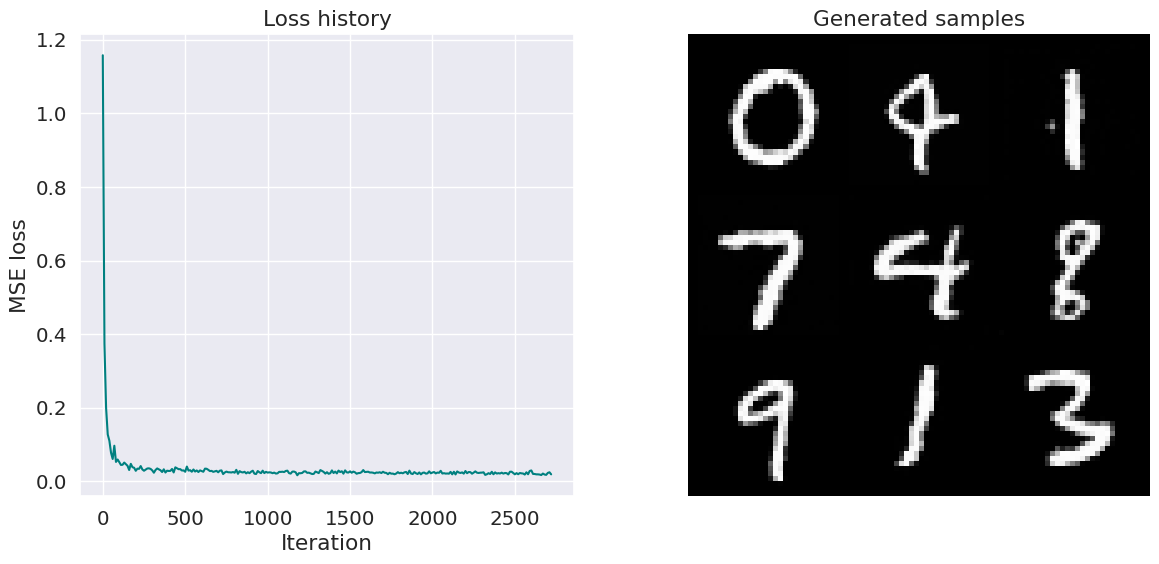

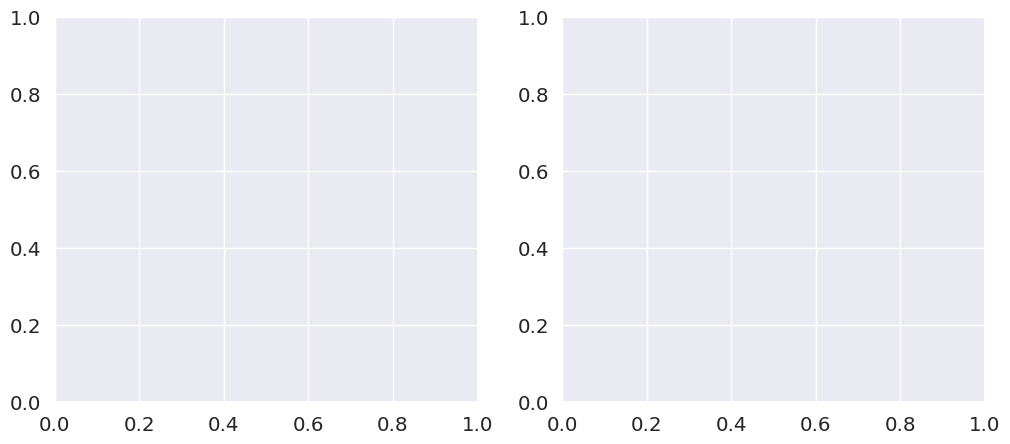

In [16]:
losses_dict = {}
models = {}
betas_dict = {}
for train_num_steps in train_num_steps_list:
    beta_start, beta_end = 1e-4, 2e-2
    beta = torch.linspace(beta_start, beta_end, train_num_steps)
    alpha = 1.0 - beta
    alpha_hat = torch.cumprod(alpha, dim=0)

    model, noise_scheduler, optimizer, lr_scheduler, criterion = init_training_modules(
        lr_warmup_steps, num_epochs, train_num_steps, beta_start, beta_end, device
    )
    models[train_num_steps] = model
    betas_dict[train_num_steps] = (beta, alpha, alpha_hat)

    losses = train_model(
        model,
        dataloader,
        noise_scheduler,
        optimizer,
        lr_scheduler,
        criterion,
        total_num_steps=train_num_steps,
        num_epochs=num_epochs,
        device=device,
        plot_interval=plot_interval,
    )
    losses_dict[train_num_steps] = losses

In [17]:
noised_images = {}
for train_num_steps in train_num_steps_list:
    beta, alpha, alpha_hat = betas_dict[train_num_steps]
    model = models[train_num_steps]

    noised_images[train_num_steps] = sample_images(
        model, 5, beta, alpha, alpha_hat, start_step=train_num_steps, device=device
    )

  0%|          | 0/999 [00:00<?, ?it/s]

Отобразим результаты восстановления из шума для каждой модели.

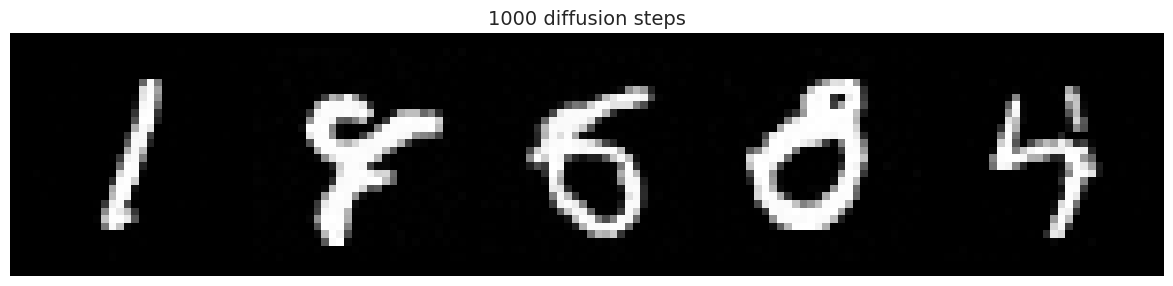

In [18]:
fig, axes = plt.subplots(
    nrows=len(noised_images), ncols=1, figsize=(12, 3 * len(noised_images))
)

if len(noised_images) == 1:
    axes = [axes]

for ax, (train_num_steps, images) in zip(axes, noised_images.items()):
    grid = make_grid(
        [unnormalize(img) for img in images],
        nrow=len(images),
    )
    img_pil = to_pil_image(grid)
    ax.imshow(img_pil)
    ax.axis("off")
    ax.set_title(f"{train_num_steps} diffusion steps", fontsize=14)

plt.tight_layout()
plt.show()

Посчитаем FID

In [19]:
def normalize_images(x, mode="auto"):
    """Надёжная нормализация к [0, 1]"""
    if mode == "auto":
        if x.min() >= 0 and x.max() <= 1:
            return x.clamp(0, 1)
        elif x.min() >= -1 and x.max() <= 1:
            return ((x + 1) / 2).clamp(0, 1)
        elif x.max() > 1:
            return (x / 255.0).clamp(0, 1)
    return x.clamp(0, 1)


@torch.no_grad()
def sample_images_ddim(
    model,
    num_images,
    alpha_hat,
    img_size,
    device,
    ddim_steps=50,
    eta=0.0,
    start_step=1000,
    finish_step=1,
):
    timesteps = torch.linspace(start_step - 1, finish_step - 1, ddim_steps).int().to(device)

    x = torch.randn(num_images, 1, img_size, img_size, device=device)

    for i, t in enumerate(tqdm(timesteps[:-1])):
        next_t = timesteps[i + 1]

        noise_pred = model(x, t.unsqueeze(0)).sample

        alpha_hat_t = alpha_hat[t]
        alpha_hat_next = alpha_hat[next_t]

        x0_pred = (x - (1 - alpha_hat_t).sqrt() * noise_pred) / alpha_hat_t.sqrt()

        sigma = (
            eta
            * ((1 - alpha_hat_next) / (1 - alpha_hat_t)).sqrt()
            * (1 - alpha_hat_t / alpha_hat_next).sqrt()
        )

        dir_xt = (1 - alpha_hat_next - sigma**2).sqrt() * noise_pred

        noise = sigma * torch.randn_like(x)

        x = alpha_hat_next.sqrt() * x0_pred + dir_xt + noise

    return x.clamp(-1, 1)


@torch.no_grad()
def compute_fid_score(real_images, fake_images, device="cpu", batch_size=64):
    assert real_images.shape[0] == fake_images.shape[0]

    real_images = normalize_images(real_images).float()
    fake_images = normalize_images(fake_images).float()

    if real_images.size(1) == 1:
        real_images = real_images.repeat_interleave(3, dim=1)
        fake_images = fake_images.repeat_interleave(3, dim=1)

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    for start in range(0, real_images.size(0), batch_size):
        r = real_images[start : start + batch_size]
        f = fake_images[start : start + batch_size]

        r = F.interpolate(r, size=(299, 299), mode="bilinear", align_corners=False)
        f = F.interpolate(f, size=(299, 299), mode="bilinear", align_corners=False)

        fid_metric.update(r.to(device), real=True)
        fid_metric.update(f.to(device), real=False)

    return fid_metric.compute().item()


@torch.no_grad()
def evaluate_fid_by_diffusion_steps(
    models_dict, dataloader, betas_dict, device="cuda", num_images_to_sample=5000
):
    fid_results = {}

    collected_real = []
    for real_imgs, _ in dataloader:
        collected_real.append(real_imgs)
        if len(collected_real) * real_imgs.shape[0] >= num_images_to_sample:
            break

    real_cat = torch.cat(collected_real, dim=0)[:num_images_to_sample]
    print(f"Real images range: [{real_cat.min():.3f}, {real_cat.max():.3f}]")

    for steps_num, model in models_dict.items():
        model.eval()
        alpha_hat = betas_dict[steps_num][2]

        print(f"Sampling {num_images_to_sample} images with {steps_num} steps...")
        fake_imgs = sample_images_ddim(
            model=model,
            num_images=num_images_to_sample,
            alpha_hat=alpha_hat,
            img_size=28,
            device=device,
            start_step=steps_num,
            finish_step=1,
        ).cpu()

        print(f"Fake images range: [{fake_imgs.min():.3f}, {fake_imgs.max():.3f}]")

        fid_value = compute_fid_score(real_cat, fake_imgs, device=device)
        fid_results[steps_num] = fid_value
        print(f"FID for {steps_num:4d} steps = {fid_value:.2f}")

    return fid_results


def plot_fid_by_diffusion_steps(fid_results):
    steps = sorted(fid_results.keys())
    fids = [fid_results[s] for s in steps]

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        range(len(steps)), fids, color=plt.cm.tab10(np.arange(len(steps)) % 10)
    )

    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels(steps, rotation=45)
    ax.set_ylabel("FID Score")
    ax.set_xlabel("Количество шагов диффузии")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar, fid in zip(bars, fids):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{fid:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

Real images range: [-1.000, 1.000]
Sampling 10000 images with 1000 steps...


  0%|          | 0/49 [00:00<?, ?it/s]

Fake images range: [-1.000, 1.000]
FID for 1000 steps = 26.56


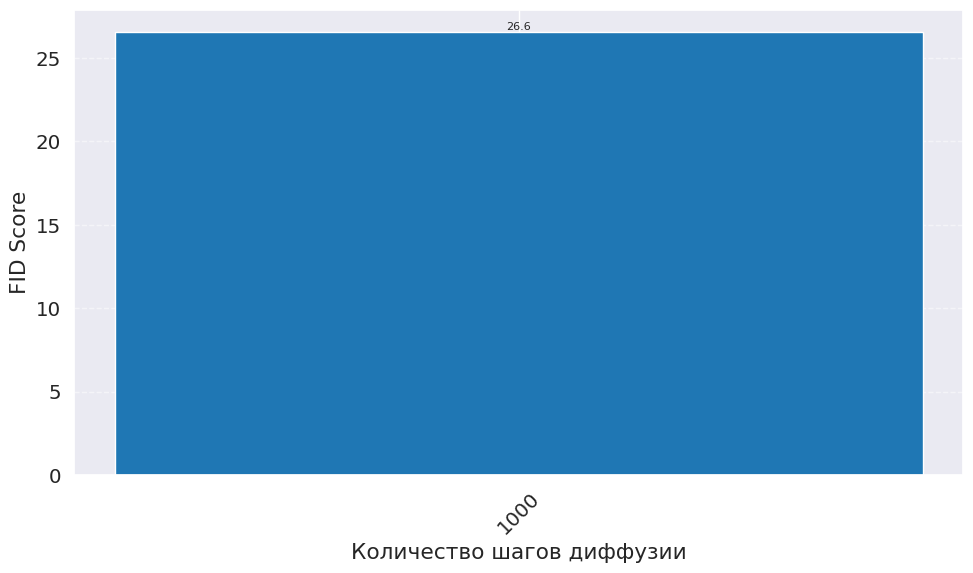

In [20]:
fid_results = evaluate_fid_by_diffusion_steps(
    models, dataloader, betas_dict, device=device, num_images_to_sample=10000
)
plot_fid_by_diffusion_steps(fid_results)

Сгенерируем изображения для лучшей модели.

  0%|          | 0/49 [00:00<?, ?it/s]

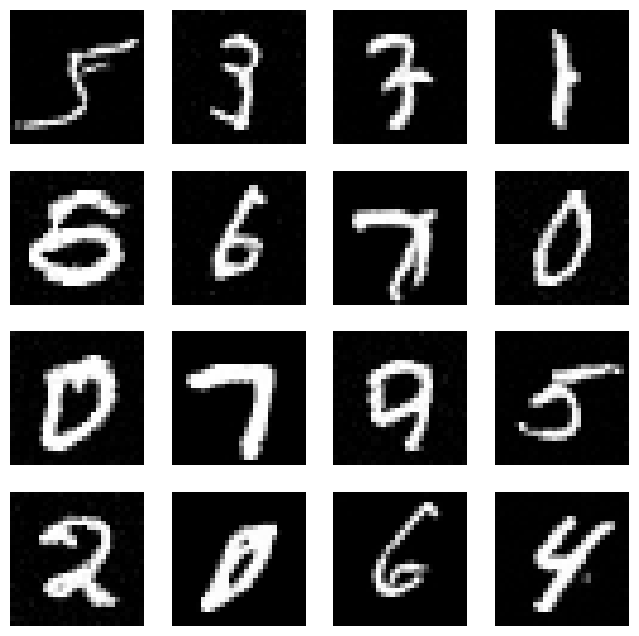

In [21]:
fake_imgs_visual = sample_images_ddim(
    model=models[1000],
    num_images=16,
    alpha_hat=betas_dict[1000][2],
    img_size=28,
    start_step=1000,
    finish_step=1,
    device=device,
).detach().cpu()

fake_imgs_visual = ((fake_imgs_visual + 1) / 2).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_imgs_visual[i, 0], cmap='gray')
    ax.axis('off')
plt.show()

Как видим, диффузионные модели работают лучше GAN-ов. В частности у диффузионных моделей меньше артефактов, а сами изображения более четкие. 

**2.** Проверьте качество инференса в зависимости от алгоритма и кол-ва шагов восстановления.
* Для модели, обучающейся на 1000 шагах диффузии, сделайте генерации, используя DDPM-инференс с меньшим количеством шагов: 500, 200, 100, 50. 
* Также сделайте инференс, используя DDIM алгоритм для 50 шагов. 
* Сравните качество генераций.

Посмотрим, что будет, если генерировать изображения с меньшим количеством шагов.

In [22]:
top_model = models[1000]

In [23]:
noised_images = {}
new_start_steps = [500, 200, 100, 50]
for train_num_steps in new_start_steps:
    beta_start, beta_end = 1e-4, 2e-2
    beta = torch.linspace(beta_start, beta_end, train_num_steps)
    alpha = 1.0 - beta
    alpha_hat = torch.cumprod(alpha, dim=0)

    noised_images[train_num_steps] = sample_images(
        top_model, 5, beta, alpha, alpha_hat, start_step=train_num_steps, device=device
    )

  0%|          | 0/499 [00:00<?, ?it/s]

  0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/99 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

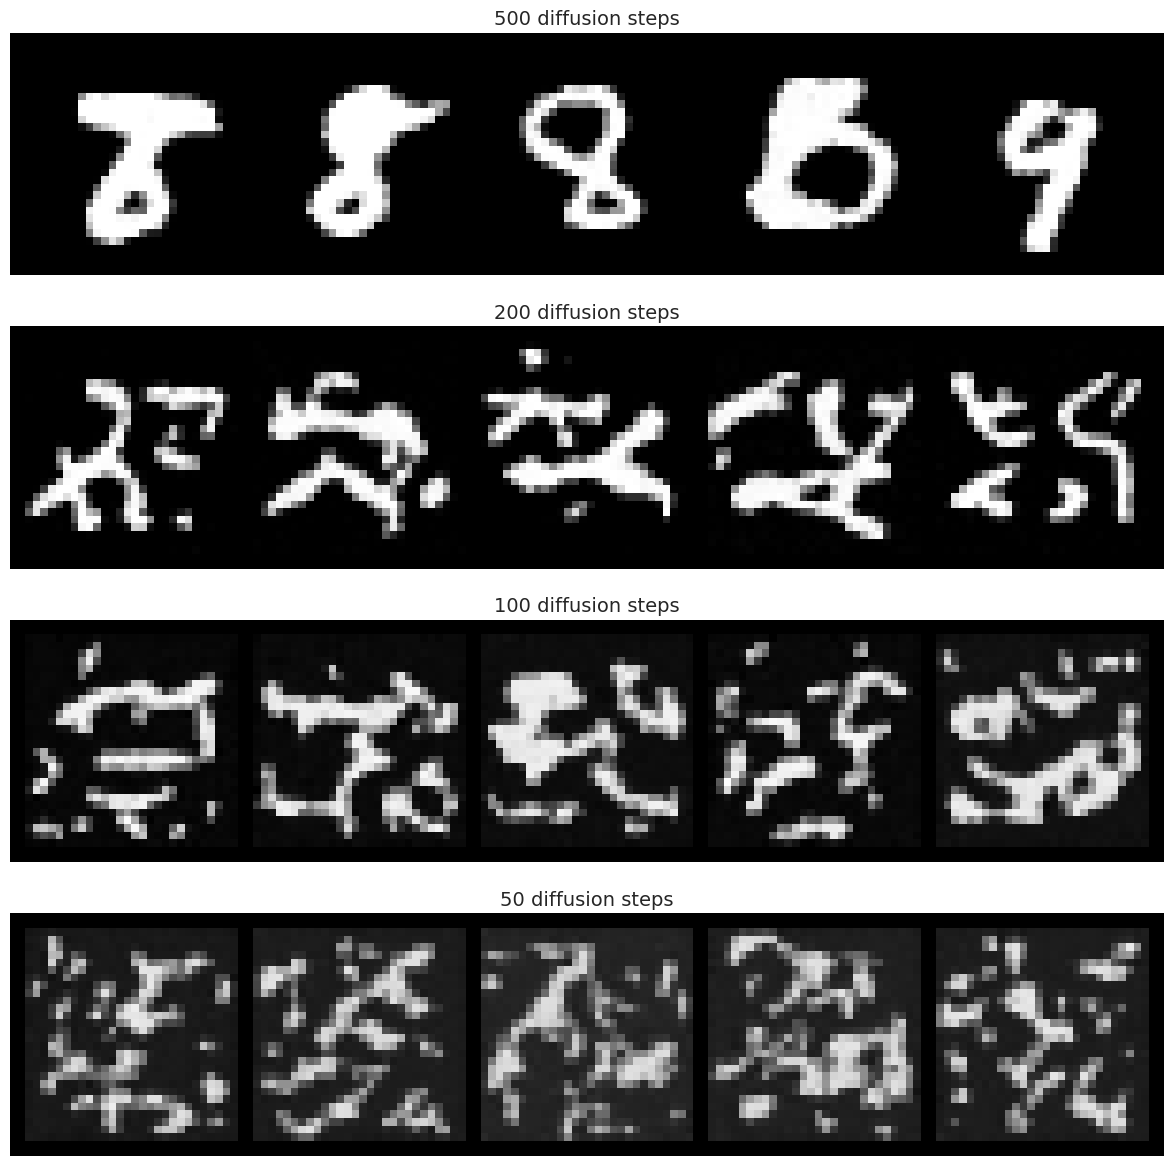

In [24]:
fig, axes = plt.subplots(
    nrows=len(noised_images), ncols=1, figsize=(12, 3 * len(noised_images))
)

if len(noised_images) == 1:
    axes = [axes]

for ax, (train_num_steps, images) in zip(axes, noised_images.items()):
    grid = make_grid(
        [unnormalize(img) for img in images],
        nrow=len(images),
    )
    img_pil = to_pil_image(grid)
    ax.imshow(img_pil)
    ax.axis("off")
    ax.set_title(f"{train_num_steps} diffusion steps", fontsize=14)

plt.tight_layout()
plt.show()

Теперь сделаем DDIM для 50 шагов:

In [25]:
train_num_steps = 50
beta, alpha, alpha_hat = betas_dict[1000]
ddim_noise_images = {}
ddim_noise_images[train_num_steps] = sample_images_ddim(
    top_model,
    5,
    alpha_hat,
    start_step=1000,
    finish_step=1,
    img_size=28,
    device=device,
    ddim_steps=50,
)

  0%|          | 0/49 [00:00<?, ?it/s]

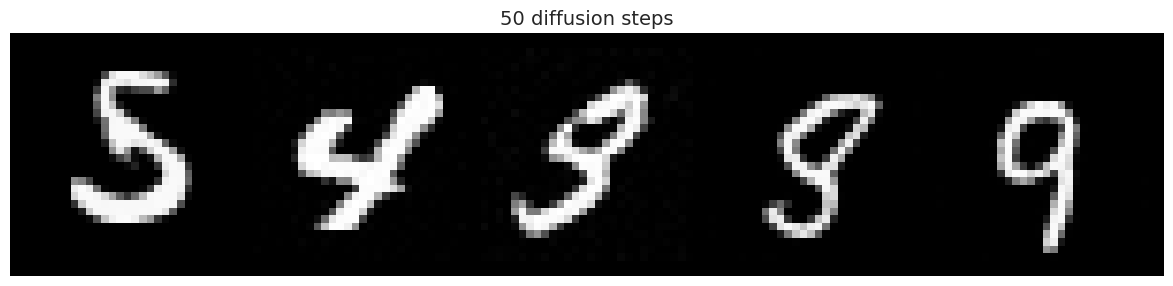

In [26]:
fig, axes = plt.subplots(
    nrows=len(ddim_noise_images), ncols=1, figsize=(12, 3 * len(ddim_noise_images))
)

if len(ddim_noise_images) == 1:
    axes = [axes]

for ax, (train_num_steps, images) in zip(axes, ddim_noise_images.items()):
    grid = make_grid(
        [unnormalize(img) for img in images],
        nrow=len(images),
    )
    img_pil = to_pil_image(grid)
    ax.imshow(img_pil)
    ax.axis("off")
    ax.set_title(f"{train_num_steps} diffusion steps", fontsize=14)

plt.tight_layout()
plt.show()

**3.** Выберите лучшую из обученных моделей диффузии. Равномерно выделите 5 шагов диффузионного процесса. Для каждого из этих шагов зафиксируйте результат генерации &mdash; получится 5 изображений разной степени зашумлённости. Затем, исходя из каждого состояния независимо, пройдите весь процесс генерации до конца и получите по 3 новых изображения для каждого шага. Таким образом на выходе вы получите 3 * (4-6) изображений для всех этапов. Отобразите в группе результаты для каждого этапа. Должно получиться что-то вроде такого:

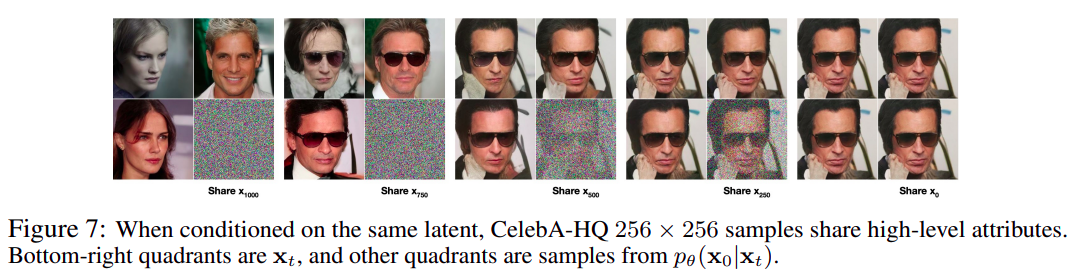

In [143]:
beta, alpha, alpha_hat = betas_dict[1000]
top_model = models[1000]
diffusion_steps = np.linspace(1000, 2, 5).astype(int)

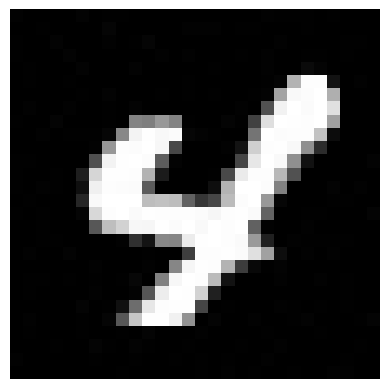

In [144]:
img = normalize_images(images[1])

img = img.squeeze(0)
plt.imshow(img.detach().cpu().numpy(), cmap='gray')

plt.axis('off')
plt.show()


In [145]:
noised_images = (torch.randn(1, 1, 28, 28)).to(device)

fake_img, full_traced = sample_images(
    top_model, 1, beta, alpha, alpha_hat, start_step=1000, device=device, noised_images=noised_images, return_full_trace=True
)

  0%|          | 0/999 [00:00<?, ?it/s]

In [146]:
diff_step_to_image = {}

for step in diffusion_steps:
    diff_step_to_image[step] = [full_traced[step - 2].squeeze(0)]

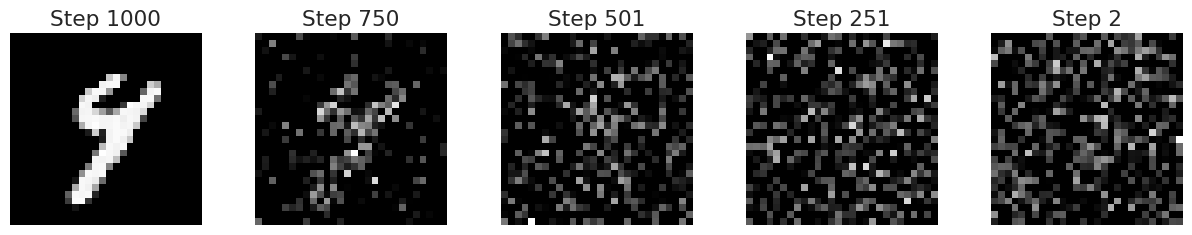

In [147]:
fig, axes = plt.subplots(
    1, len(diff_step_to_image), figsize=(len(diff_step_to_image) * 2.5, 2.5)
)

if len(diff_step_to_image) == 1:
    axes = [axes]

for ax, (step, fake_img) in zip(axes, sorted(diff_step_to_image.items(), reverse=True)):
    img = normalize_images(fake_img[0].detach().cpu())

    img = img.squeeze(0)
    ax.imshow(img.numpy(), cmap="gray")

    ax.set_title(f"Step {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [148]:
for step in diffusion_steps:
    new_steps = np.linspace(step, 1000, 4)[1:].astype(int)
    
    curr_image = diff_step_to_image[step][0].to(device)
    for new_step in new_steps:
        fake_img = sample_images(
            top_model,
            1,
            beta,
            alpha,
            alpha_hat,
            start_step=new_step,
            device=device,
            noised_images=curr_image.unsqueeze(0),
        )[0]
        diff_step_to_image[step].append(fake_img)

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/915 [00:00<?, ?it/s]

...

  0%|          | 0/749 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/333 [00:00<?, ?it/s]

  0%|          | 0/666 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

In [150]:
def plot_denoising_progress(diff_step_to_image, diffusion_steps):
    n_rows = len(diffusion_steps)
    n_cols = len(diff_step_to_image[diffusion_steps[0]])

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5), squeeze=False
    )

    sorted_steps = sorted(diffusion_steps, reverse=True)

    for row_idx, step in enumerate(sorted_steps):
        images_list = diff_step_to_image[step]

        for col_idx, img_tensor in enumerate(images_list):
            ax = axes[row_idx, col_idx]

            img = normalize_images(img_tensor)
            img = img.squeeze(0).detach().cpu().numpy()

            ax.imshow(img, cmap="gray")

            if col_idx == 0:
                ax.set_title(
                    f"Start Step: {step}\n(original)", fontsize=10, fontweight="bold"
                )
            else:
                ax.set_title(f"Denoised {col_idx}", fontsize=9)

            ax.axis("off")

    fig.suptitle(
        "Denoising Process Progression\n(left to right: less to more denoised)",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

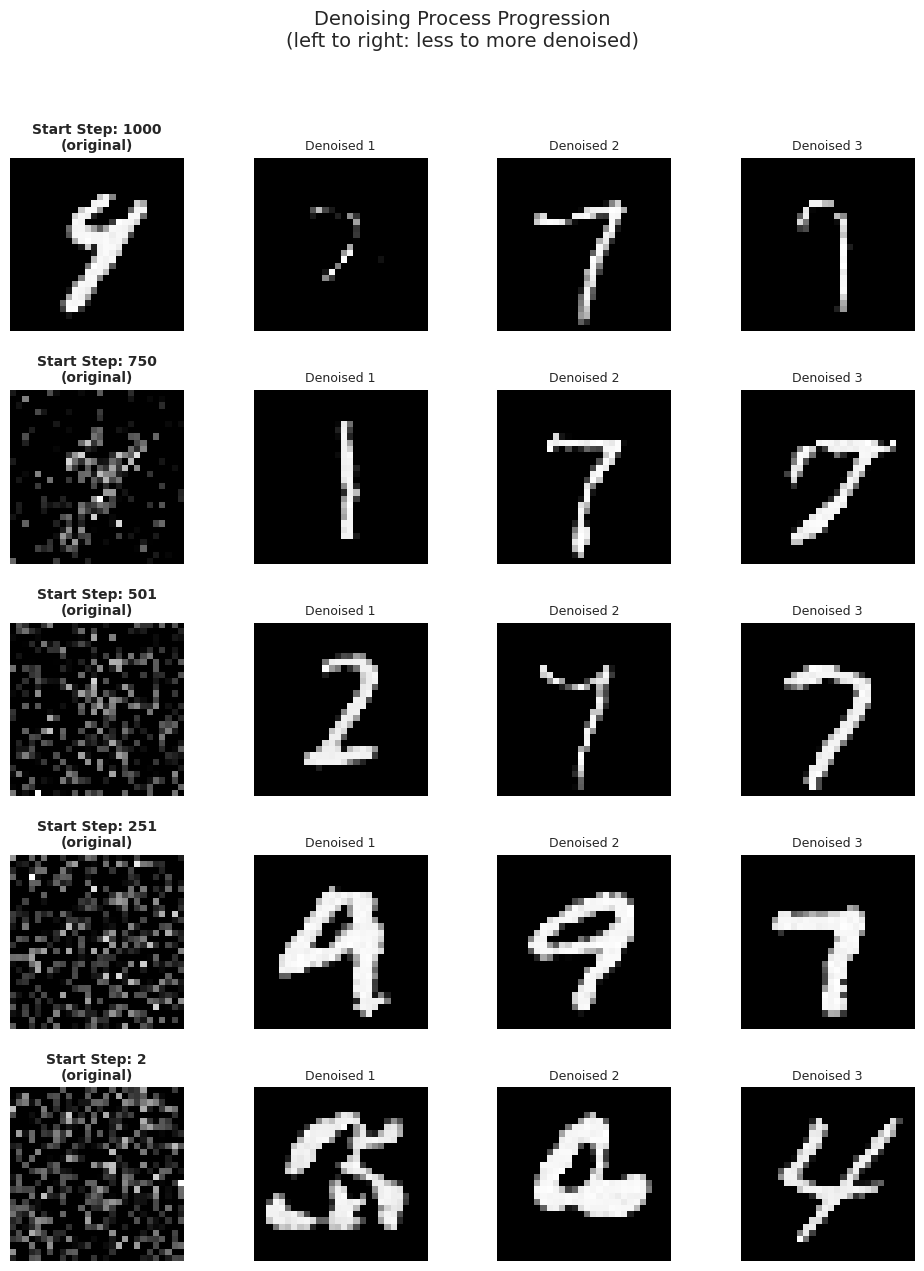

In [151]:
plot_denoising_progress(diff_step_to_image, diffusion_steps)

Как можно интерпретировать полученные результаты?

Забавно, но часто мы от зашумления на разных шагах в итоге приходим к одной и той же картинке. То есть для модели в кажущемся нам шуме уже есть какие то паттерны, где она распознает нужную цифру.

**Выводы:**

Мы посмотрели на работ DDPM и DDIM. Убедились, что они хоть обучаются дольше, но выдают более качественные картинки. Убедились, что для диффузионных моделей критически важно количество шагов диффузии, так как иначе они просто не обучаются.

Также в конце мы убедились, что модель даже на ранних этапах уже видит паттерны финальной картинки, а поэтому не так важно с какого шага ее довосстанавливать -- скорее всего все равно получим одно и то же изображение.

In [153]:
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

### Задача 2. Условная генерация

**1.** Реализация условной диффузионной модели.
* Реализуйте условную диффузионную модель. Она должна уметь генерировать изображения цифр, основываясь на предоставленной метке класса, т.е. если мы подаем в модель метку класса "5", модель должна генерировать только пятерки. Для этого достаточно подобрать соответствующую модель unet-а из [diffusers](https://huggingface.co/docs/diffusers/main/en/api/models/unet2d-cond#diffusers.UNet2DConditionModel), а также адаптировать код обучения и генерации. 
* Обучите условную модель на MNIST.
* Сравните FID этой модели с предыдущими моделями. Сделайте вывод.

Input shape: torch.Size([128, 1, 28, 28])
Labels: tensor([3, 3, 9, 5, 8, 1, 7, 9, 1, 1, 3, 3, 0, 2, 8, 1, 4, 4, 6, 4, 4, 9, 7, 8,
        9, 4, 2, 0, 1, 3, 3, 1, 7, 9, 2, 2, 3, 6, 9, 5, 5, 3, 9, 0, 4, 9, 7, 0,
        1, 2, 0, 5, 4, 3, 5, 1, 8, 8, 0, 3, 4, 5, 3, 9, 9, 7, 5, 4, 8, 8, 5, 7,
        1, 6, 4, 2, 5, 0, 3, 9, 2, 2, 6, 6, 6, 3, 5, 3, 5, 0, 2, 6, 1, 0, 2, 5,
        4, 7, 1, 0, 0, 3, 1, 9, 5, 7, 5, 1, 8, 3, 5, 0, 6, 4, 9, 9, 4, 0, 8, 9,
        1, 2, 7, 4, 4, 5, 4, 0])


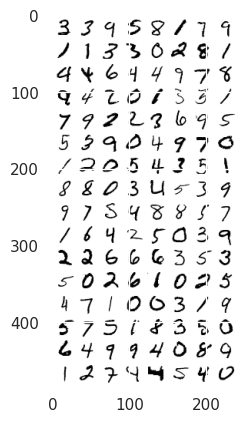

In [203]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())

train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# View some examples
x, y = next(iter(train_dataloader))
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

In [204]:
class ClassConditionedUnet(nn.Module):
  def __init__(self, num_classes=10, class_emb_size=4):
    super().__init__()
    
    # The embedding layer will map the class label to a vector of size class_emb_size
    self.class_emb = nn.Embedding(num_classes, class_emb_size)

    # Self.model is an unconditional UNet with extra input channels to accept the conditioning information (the class embedding)
    self.model = UNet2DModel(
        sample_size=28,           # the target image resolution
        in_channels=1 + class_emb_size, # Additional input channels for class cond.
        out_channels=1,           # the number of output channels
        layers_per_block=2,       # how many ResNet layers to use per UNet block
        block_out_channels=(32, 64, 64), 
        down_block_types=( 
            "DownBlock2D",        # a regular ResNet downsampling block
            "AttnDownBlock2D",    # a ResNet downsampling block with spatial self-attention
            "AttnDownBlock2D",
        ), 
        up_block_types=(
            "AttnUpBlock2D", 
            "AttnUpBlock2D",      # a ResNet upsampling block with spatial self-attention
            "UpBlock2D",          # a regular ResNet upsampling block
          ),
    )

  # Our forward method now takes the class labels as an additional argument
  def forward(self, x, t, class_labels):
    # Shape of x:
    bs, ch, w, h = x.shape
    
    # class conditioning in right shape to add as additional input channels
    class_cond = self.class_emb(class_labels) # Map to embedding dimension
    class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1).expand(bs, class_cond.shape[1], w, h)
    # x is shape (bs, 1, 28, 28) and class_cond is now (bs, 4, 28, 28)

    # Net input is now x and class cond concatenated together along dimension 1
    net_input = torch.cat((x, class_cond), 1) # (bs, 5, 28, 28)

    # Feed this to the UNet alongside the timestep and return the prediction
    return self.model(net_input, t).sample # (bs, 1, 28, 28)

In [205]:
NUM_EPOCHS=10

  0%|          | 0/469 [00:00<?, ?it/s]

Finished epoch 0. Average of the last 100 loss values: 0.033872


  0%|          | 0/469 [00:00<?, ?it/s]

Finished epoch 1. Average of the last 100 loss values: 0.028206


  0%|          | 0/469 [00:00<?, ?it/s]

...

Finished epoch 7. Average of the last 100 loss values: 0.023446


  0%|          | 0/469 [00:00<?, ?it/s]

Finished epoch 8. Average of the last 100 loss values: 0.022894


  0%|          | 0/469 [00:00<?, ?it/s]

Finished epoch 9. Average of the last 100 loss values: 0.022613


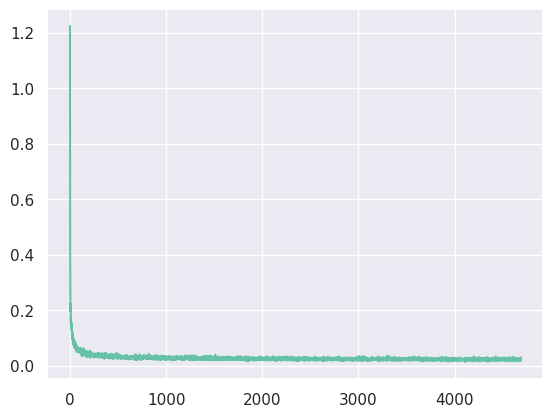

In [206]:
n_epochs = NUM_EPOCHS
net = ClassConditionedUnet().to(device)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=1e-3) 
losses = []
for epoch in range(n_epochs):
    for x, y in tqdm(train_dataloader):
        x = x.to(device) * 2 - 1 # Data on the GPU (mapped to (-1, 1))
        y = y.to(device)
        noise = torch.randn_like(x)
        timesteps = torch.randint(0, 999, (x.shape[0],)).long().to(device)
        noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

        # Get the model prediction
        pred = net(noisy_x, timesteps, y) # Note that we pass in the labels y

        # Calculate the loss
        loss = loss_fn(pred, noise) # How close is the output to the noise

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print out the average of the last 100 loss values to get an idea of progress:
    avg_loss = sum(losses[-100:])/100
    print(f'Finished epoch {epoch}. Average of the last 100 loss values: {avg_loss:05f}')

    # View the loss curve
plt.plot(losses)

0it [00:00, ?it/s]

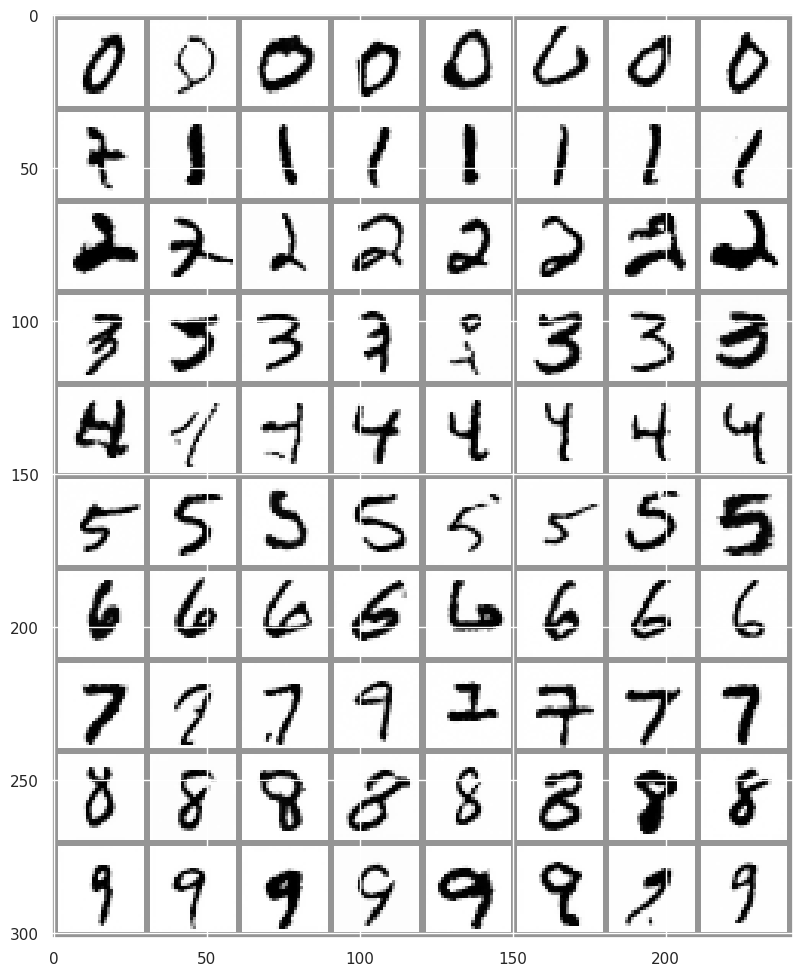

In [207]:
# Prepare random x to start from, plus some desired labels y
x = torch.randn(80, 1, 28, 28).to(device)
y = torch.tensor([[i]*8 for i in range(10)]).flatten().to(device)

# Sampling loop
for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    # Get model pred
    with torch.no_grad():
        residual = net(x, t, y)  # Again, note that we pass in our labels y

    # Update sample with step
    x = noise_scheduler.step(residual, t, x).prev_sample

# Show the results
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0], cmap='Greys')

In [ ]:
@torch.no_grad()
def compute_fid_score(real_images, fake_images, device="cuda", batch_size=64):
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    real_images = normalize_images(real_images).float()
    fake_images = normalize_images(fake_images).float()

    if real_images.size(1) == 1:
        real_images = real_images.repeat(1, 3, 1, 1)
        fake_images = fake_images.repeat(1, 3, 1, 1)

    for start_idx in range(0, real_images.size(0), batch_size):
        r = real_images[start_idx : start_idx + batch_size]
        f = fake_images[start_idx : start_idx + batch_size]

        r = interpolate(r, (299, 299), mode="bilinear", align_corners=False)
        f = interpolate(f, (299, 299), mode="bilinear", align_corners=False)

        fid_metric.update((r * 255).byte(), real=True)
        fid_metric.update((f * 255).byte(), real=False)

    fid = fid_metric.compute().item()
    print(f"FID = {fid:.2f}")
    return fid


@torch.no_grad()
def sample_ddpm(
    model,
    n_samples,
    class_labels,
    noise_scheduler,
    device="cuda",
    img_size=28,
    is_full_traced=False,
):
    model.eval()
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)
    classes = class_labels.to(device)
    full_traced = []

    for t in tqdm(noise_scheduler.timesteps):
        timestep = torch.full((n_samples,), t, device=device, dtype=torch.long)
        pred_noise = model(x, timestep, classes)
        step_output = noise_scheduler.step(pred_noise, t, x)
        x = step_output.prev_sample

        if is_full_traced:
            full_traced.append(x.clone())

    x = ((x + 1) / 2).clamp(0, 1)
    if is_full_traced:
        return x, full_traced
    
    return x

In [224]:
real_images = []
labels = []

for x, y in train_dataloader:
    real_images.append(x)
    labels.append(y)
    if len(real_images) * x.size(0) >= 5000:
        break

real_images = torch.cat(real_images, dim=0)[:5000]
labels = torch.cat(labels, dim=0)[:5000]
fake_images = sample_ddpm(net, n_samples=5000, class_labels=labels,
                          noise_scheduler=noise_scheduler, device=device)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [225]:
real_images = real_images.to(device)
fake_images = fake_images.to(device)

fid = compute_fid_score(real_images, fake_images, device=device)
print(f"Final FID: {fid:.2f}")

FID = 186.11
Final FID: 186.11


**2.** Равномерно выделите 5 шагов диффузионного процесса. Для всех классов просемплируйте результаты генерации для этих шагов несколько раз. Для каждого шага отобразите результаты генерации в двумерное пространство с помощью UMAP и нарисуйте соответствующий график. Разные классы отобразите разными цветами. Сделайте выводы.

In [221]:
noised_images = (torch.randn(1, 1, 28, 28)).to(device)
labels = torch.arange(0, 10)

fake_img, full_traced = sample_ddpm(
    net,
    n_samples=10,
    class_labels=labels,
    noise_scheduler=noise_scheduler,
    device=device,
    is_full_traced=True,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [222]:
full_traced[0].shape

torch.Size([10, 1, 28, 28])

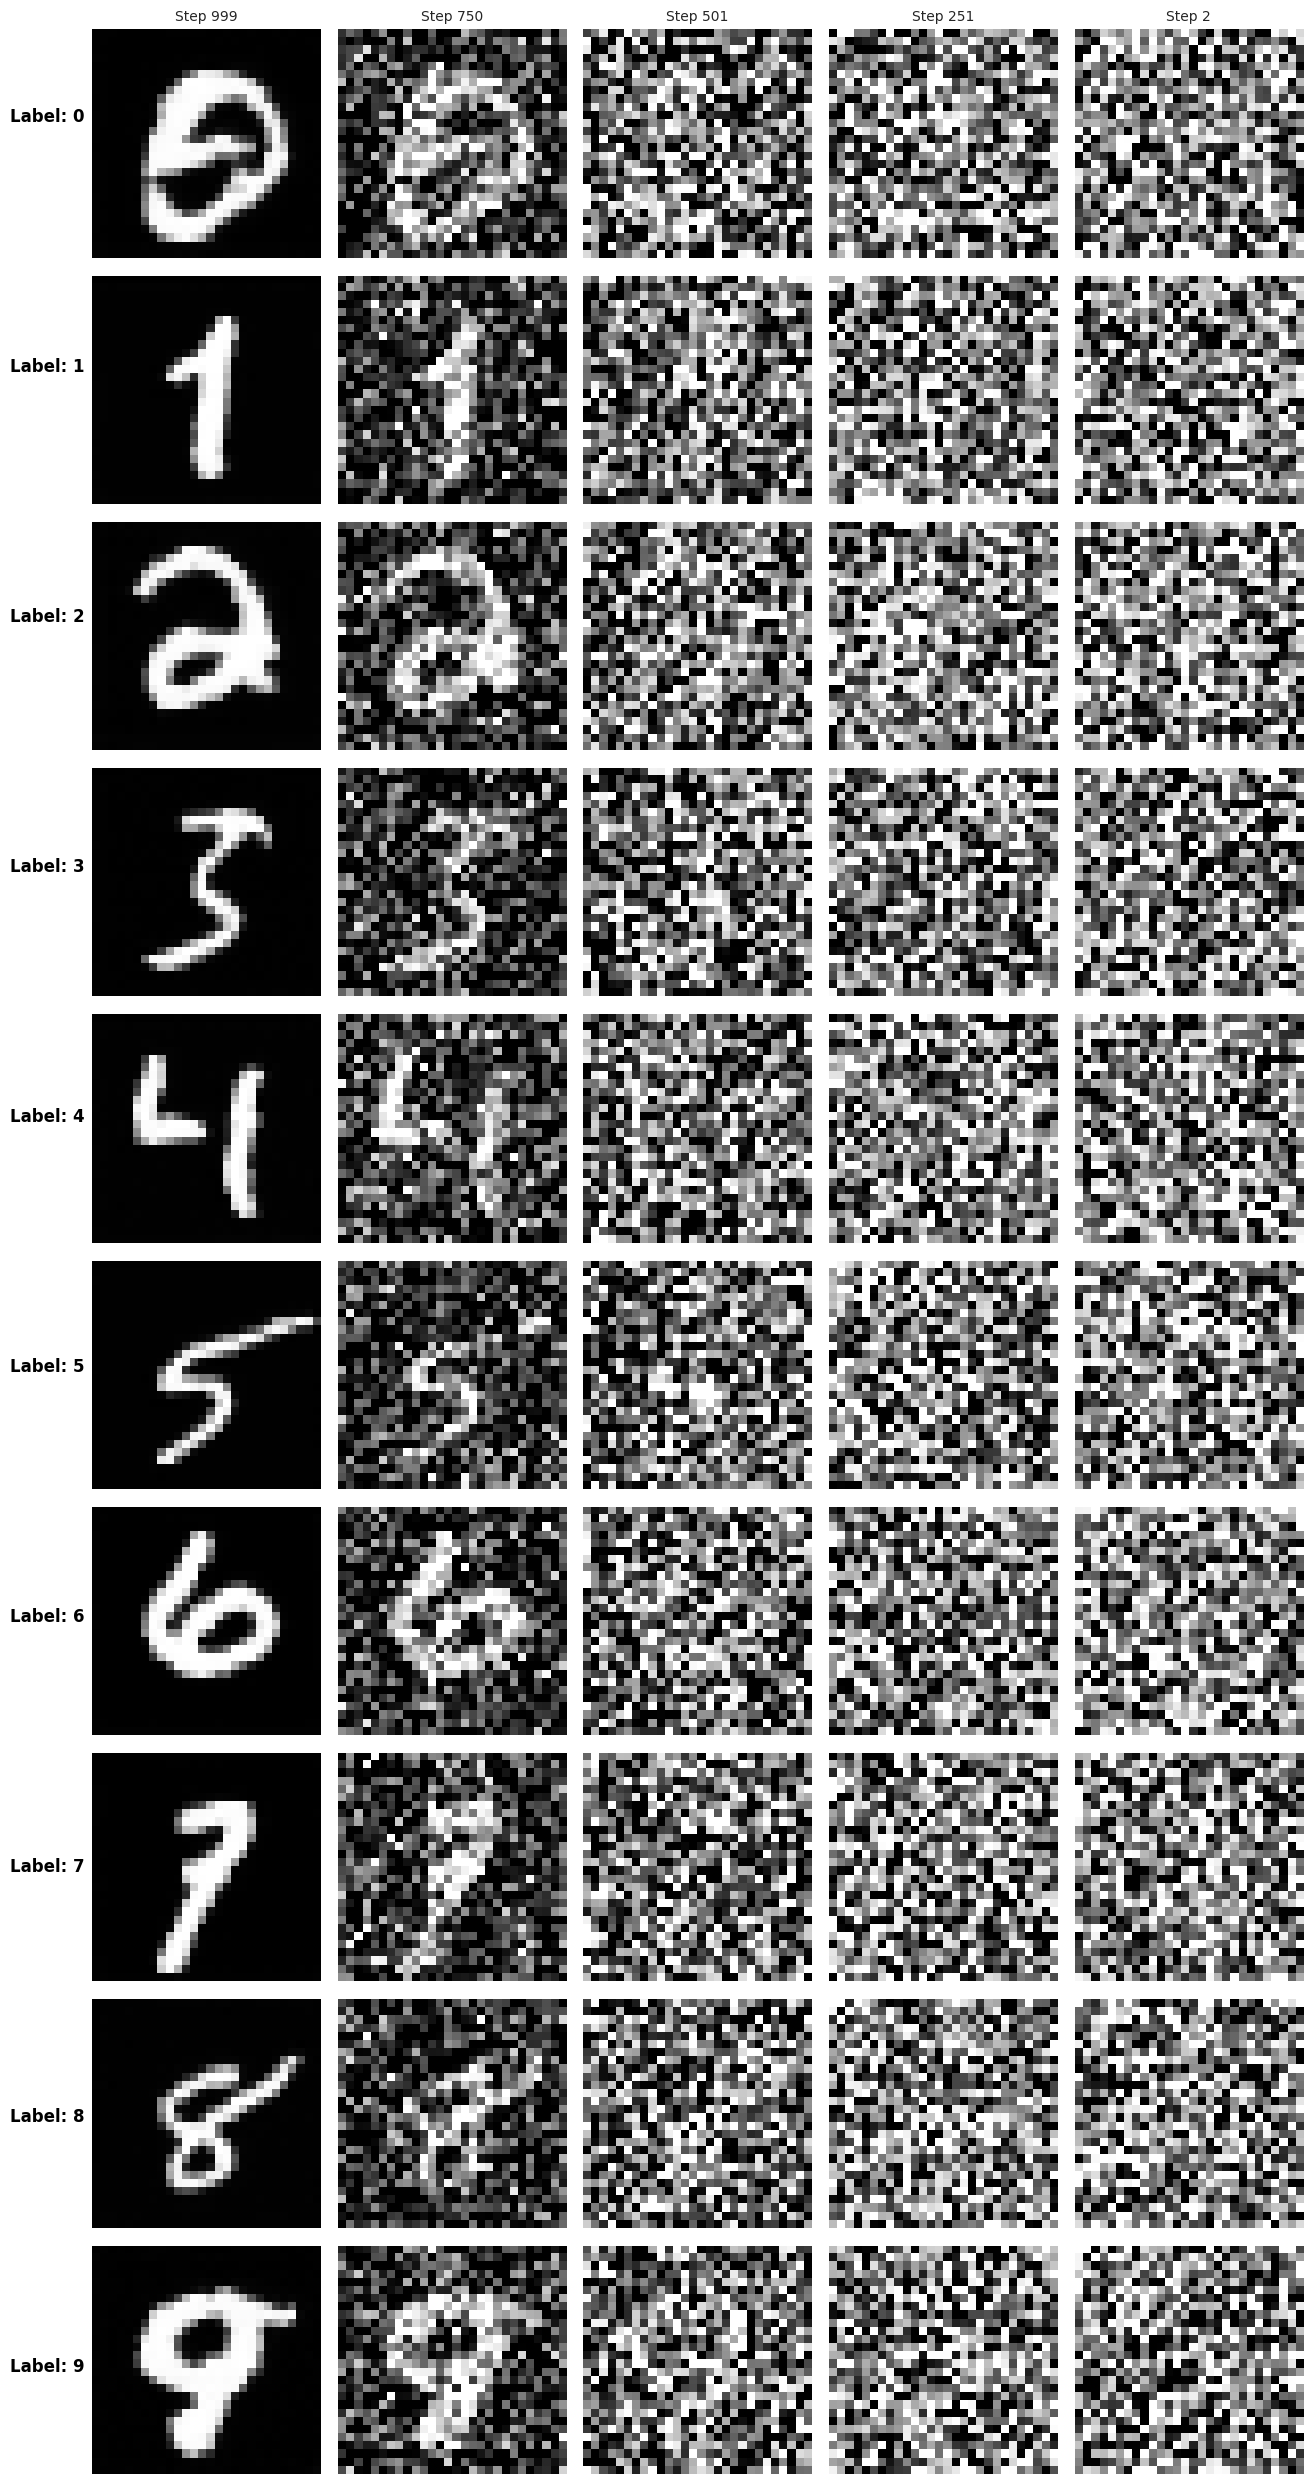

In [223]:
def to_display(x):
    x = (x.detach().cpu() + 1) / 2
    x = x.clamp(0, 1)
    if x.ndim == 3 and x.shape[0] == 1:
        x = x.squeeze(0)
        return x.numpy(), "gray"
    else:
        return x.permute(1, 2, 0).numpy(), None

timesteps_to_show = diffusion_steps
timesteps_to_show = [min(t, len(full_traced) - 1) for t in timesteps_to_show]

n_rows = len(labels)
n_cols = len(timesteps_to_show)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))

axes = np.array(axes, ndmin=2)

for row_idx, cls in enumerate(labels):
    for col_idx, step in enumerate(timesteps_to_show):
        img = full_traced[step][row_idx]

        arr, cmap = to_display(img)
        ax = axes[row_idx, col_idx]
        ax.imshow(arr, cmap=cmap)
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(f"Step {step}", fontsize=10)
    
    axes[row_idx, 0].set_ylabel(
        f"Class {cls.item()}",
        rotation=90,
        fontsize=10,
        labelpad=20,
        va='center'
    )
    
    fig.text(
        -0.05, 
        (n_rows - row_idx - 0.5) / n_rows, 
        f"Label: {cls.item()}",
        fontsize=12,
        fontweight="bold",
        va='center',
        ha='left',
        color="black"
    )

plt.tight_layout()
plt.show()

Теперь отобразим кластеры при помощи UMAP

In [ ]:
n_per_class = 250
labels_all = []
images_all = []

net.eval()
with torch.no_grad():
    for cls in range(10):
        class_labels = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        fake_img = sample_ddpm(
            model=net,
            n_samples=n_per_class,
            class_labels=class_labels,
            noise_scheduler=noise_scheduler,
            device=device,
            is_full_traced=False
        )
        images_all.append(fake_img)
        labels_all.append(class_labels.cpu())

images_all = torch.cat(images_all, dim=0).cpu()
labels_all = torch.cat(labels_all, dim=0).numpy()

print("Сгенерировано изображений:", images_all.shape)

X = images_all.reshape(images_all.shape[0], -1).numpy()

reducer = UMAP(n_components=2, random_state=42)
emb = reducer.fit_transform(X)

plt.figure(figsize=(8,6))
scatter = plt.scatter(emb[:,0], emb[:,1], c=labels_all, cmap="tab10", s=30, edgecolor='none')
plt.colorbar(scatter, ticks=range(10))
plt.title("UMAP‑проекция сгенерированных изображений по классам")
plt.xlabel("UMAP‑1")
plt.ylabel("UMAP‑2")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

**3.** Реализуйте classifier-free-guidance метод.
* Проведите файнтюнинг условной модели генерации. Он практически не отличается от стандартного обучения, кроме того, что в 20% случаев (можно попробовать другой % случаев) должен подаваться пустой класс вместо правильного. 
* Сделайте инференс для с разными guidance весами: 1, 2, 3, 5, 7, 10. 
* Сделайте выводы.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока